# TimeGPT Rolling Forecast - CO1 Comdty (Brent Oil)

Bu notebook, **CO1 Comdty (Brent Oil)** için TimeGPT rolling forecast stratejisi ve VectorBT backtesting yapar.

In [74]:
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
from nixtla import NixtlaClient
import os
from dotenv import load_dotenv
import logging

import warnings
warnings.filterwarnings('ignore')

# TimeGPT INFO loglarını kapat
logging.getLogger("nixtla").setLevel(logging.WARNING)

load_dotenv()
NIXTLA_API_KEY = os.getenv("NIXTLA_API_KEY")
nixtla_client = NixtlaClient(api_key=NIXTLA_API_KEY)

In [75]:
# Veriyi yükle
df = pd.read_csv('commodity_features.csv')

# Tarihi index yap
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"Veri boyutu: {df.shape}")
print(f"Tarih aralığı: {df.index.min()} - {df.index.max()}")
df.head()

Veri boyutu: (8101, 237)
Tarih aralığı: 2003-04-11 00:00:00 - 2025-06-14 00:00:00


,CO1 Comdty,CL1 Comdty,GC1 Comdty,HG1 Comdty,HO1 Comdty,NG1 Comdty,PA1 Comdty,PL1 Comdty,SI1 Comdty,C 1 Comdty,...,XAGUSDV3M Curncy,XAGUSDV6M Curncy,XAGUSDV1Y Curncy,CESIUSD Index,CDSPHRAV Index,WIRAWRLD Index,WCHMLS Index,WELUTLS Index,WLS555T Index,EEM US Equity
date,,,,,,,,,,,,,,,,,,,,,
2003-04-11,24.75,28.14,327.9,72.55,72.45,5.411,172.0,628.7,4.493,239.25,...,17.50,17.00,17.00,-76.4,3160.0,2446620.0,1019.70,1026.05,973.44,65.8430
2003-04-12,24.75,28.14,327.9,72.55,72.45,5.411,172.0,628.7,4.493,239.25,...,17.50,17.00,17.00,-76.4,3160.0,2446620.0,1019.70,1026.05,973.44,65.8430
2003-04-13,24.75,28.14,327.9,72.55,72.45,5.411,172.0,628.7,4.493,239.25,...,17.50,17.00,17.00,-76.4,3160.0,2446620.0,1019.70,1026.05,973.44,65.8430
2003-04-14,24.99,28.63,324.2,72.45,74.75,5.552,168.0,633.0,4.538,239.25,...,17.50,17.00,17.00,-71.8,3155.0,2446620.0,1027.86,1035.07,961.76,66.7015
2003-04-15,25.20,29.29,324.9,73.40,77.26,5.653,164.0,632.6,4.523,241.75,...,16.25,16.25,16.25,-77.2,3155.0,2446620.0,1037.26,1043.69,976.50,67.4940


In [76]:
# CO1 Comdty (Brent Oil) fiyatlarını al
co1_prices = df['CO1 Comdty'].copy()

# Eksik değerleri forward fill ile doldur
co1_prices = co1_prices.fillna(method='ffill').dropna()

print("Seçilen Commodity: CO1 Comdty (Brent Oil)")
print(f"Veri noktası sayısı: {len(co1_prices)}")
print(f"İlk fiyat: ${co1_prices.iloc[0]:.2f}")
print(f"Son fiyat: ${co1_prices.iloc[-1]:.2f}")
print(f"Ortalama fiyat: ${co1_prices.mean():.2f}")

co1_prices.head()

Seçilen Commodity: CO1 Comdty (Brent Oil)
Veri noktası sayısı: 8101
İlk fiyat: $24.75
Son fiyat: $74.56
Ortalama fiyat: $73.09


date
2003-04-11    24.75
2003-04-12    24.75
2003-04-13    24.75
2003-04-14    24.99
2003-04-15    25.20
Name: CO1 Comdty, dtype: float64

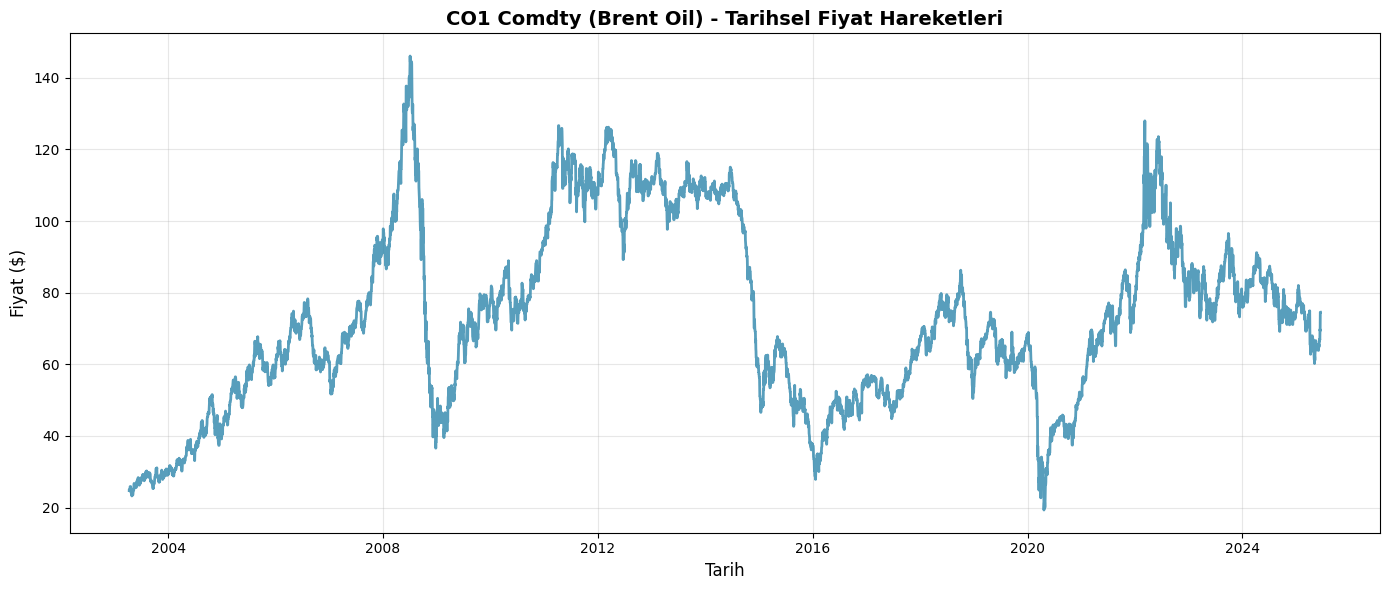

In [77]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(co1_prices.index, co1_prices.values, linewidth=2, color='#2E86AB', alpha=0.8)

ax.set_xlabel('Tarih', fontsize=12)
ax.set_ylabel('Fiyat ($)', fontsize=12)
ax.set_title('CO1 Comdty (Brent Oil) - Tarihsel Fiyat Hareketleri', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Rolling Forecast Strategy (CO1 Comdty)

**CO1 Comdty (Brent Oil)** için rolling forecast 
- Her gün için bir sonraki günü tahmin ettim
- Tahmine göre alım/satım kararı 
- VectorBT ile backtesting 

In [78]:
def rolling_forecast_co1(prices_series,
                        train_size=252,
                        refit_frequency=5,
                        max_horizon=5,
                        threshold=0.005):
    """
    CO1 Comdty için Rolling forecast ile backtesting stratejisi (çok adımlı kullanım)

    Mantık:
    - Refit gününde h = max_horizon kadar (örn. 5) ileriye çok adımlı tahmin üretir.
    - Refit olmayan günlerde, son refit'te üretilmiş tahminde ilgili adımı (t+1, t+2 ...)
      sırayla kullanır. Böylece refit_frequency=5 ise haftalık güncelleme, aradaki günlerde
      bayat (stale) kalmadan sıradaki adım kullanılır.

    Parameters
    ----------
    prices_series : pd.Series
        CO1 fiyat serisi (date index'li)
    train_size : int
        Minimum eğitim verisi boyutu (252 = 1 yıl)
    refit_frequency : int
        Kaç günde bir model yeniden eğitilecek (örn. 5 = haftalık)
    max_horizon : int
        Refit gününde üretilecek tahmin adımı sayısı (örn. 5 gün ileri)
    threshold : float
        İşlem sinyali için getiri eşiği (0.005 = %0.5)

    Returns
    -------
    results : pd.DataFrame
        Tahminler, gerçek değerler, sinyaller
    """
    from tqdm import tqdm

    results = []

    # Test setini belirle (son %20)
    test_start_idx = int(len(prices_series) * 0.8)
    print(f"📊 Rolling Forecast Başlatılıyor...")
    print(f"   Toplam veri: {len(prices_series)} gün")
    print(f"   Train bölümü: 0 - {test_start_idx} gün (ilk %80)")
    print(f"   Test bölümü: {test_start_idx} - {len(prices_series)} gün (son %20)")
    print(f"   Test seti boyutu: {len(prices_series) - test_start_idx} gün")
    print(f"   Refit frequency: {refit_frequency} gün")
    print(f"   max_horizon (h): {max_horizon} gün")
    print("="*60)

    last_fit_idx = -1
    last_forecast = None
    refit_count = 0

    # Her test günü için tahmin yap (t günü kararı, t+1 getirisi hedeflenir)
    for i in tqdm(range(test_start_idx, len(prices_series) - 1), desc="Rolling Forecast", ncols=100):
        current_date = prices_series.index[i]
        actual_price = prices_series.iloc[i]
        future_price = prices_series.iloc[i + 1]  # t->t+1 gerçekleşen getiri için

        # Refit kontrolü
        if (i - last_fit_idx >= refit_frequency) or (last_fit_idx == -1):
            train_data = prices_series.iloc[:i]
            if len(train_data) < train_size:
                continue

            timegpt_df = pd.DataFrame({
                'ds': train_data.index,
                'y': train_data.values
            })

            try:
                forecast = nixtla_client.forecast(
                    df=timegpt_df,
                    h=max_horizon,
                    freq='D'
                )
                last_forecast = forecast
                last_fit_idx = i
                refit_count += 1
                step_offset = 0  # refit günü için t+1 tahmini
            except Exception:
                if last_forecast is None:
                    continue
                step_offset = 0
        else:
            # Refit olmayan gün: aynı forecast içinden ilgili adımı kullan
            step_offset = i - last_fit_idx
            if last_forecast is None:
                continue
            if step_offset >= max_horizon:
                # Tahmin penceresi bitti, refit bekleniyor
                continue

        # İlgili adımın tahmini
        predicted_price = last_forecast['TimeGPT'].iloc[step_offset]

        # Basit debug: ilk 8 iterasyonda hangi step kullanıldı, tarihle yazdır
        if i - test_start_idx < 8:
            print(f"[debug] {current_date.date()} -> step={step_offset+1} (t+{step_offset+1})")

        expected_return = (predicted_price - actual_price) / actual_price

        if expected_return > threshold:
            signal = 1  # AL
        elif expected_return < -threshold:
            signal = -1  # SAT
        else:
            signal = 0  # TUT

        results.append({
            'date': current_date,
            'actual_price': actual_price,
            'predicted_price': predicted_price,
            'future_actual_price': future_price,
            'expected_return': expected_return,
            'actual_return': (future_price - actual_price) / actual_price,
            'signal': signal,
            'step_used': step_offset + 1
        })

    results_df = pd.DataFrame(results)
    results_df.set_index('date', inplace=True)

    print(f"\n✅ Rolling Forecast Tamamlandı!")
    print(f"   Toplam tahmin: {len(results_df)}")
    print(f"   Toplam refit: {refit_count} kez")

    return results_df


### Rolling Forecast Çalıştır

In [79]:
# CO1 Comdty için rolling forecast stratejisi çalıştır
rolling_results = rolling_forecast_co1(
    prices_series=co1_prices,
    train_size=252,  # 1 yıllık minimum train data
    refit_frequency=5,  # Her 5 günde bir yeniden eğit (haftalık)
    max_horizon=5,     # Refit gününde 5 adım ileri tahmin üret
    threshold=0.01    # %1 eşik
 )

print("\n📈 Rolling Forecast Sonuçları:")
print(rolling_results.head(10))

📊 Rolling Forecast Başlatılıyor...
   Toplam veri: 8101 gün
   Train bölümü: 0 - 6480 gün (ilk %80)
   Test bölümü: 6480 - 8101 gün (son %20)
   Test seti boyutu: 1621 gün
   Refit frequency: 5 gün
   max_horizon (h): 5 gün


Rolling Forecast:   0%|                                            | 1/1620 [00:01<33:49,  1.25s/it]

[debug] 2021-01-06 -> step=1 (t+1)
[debug] 2021-01-07 -> step=2 (t+2)
[debug] 2021-01-08 -> step=3 (t+3)
[debug] 2021-01-09 -> step=4 (t+4)
[debug] 2021-01-10 -> step=5 (t+5)


Rolling Forecast:   0%|▏                                           | 6/1620 [00:01<07:12,  3.73it/s]

[debug] 2021-01-11 -> step=1 (t+1)
[debug] 2021-01-12 -> step=2 (t+2)
[debug] 2021-01-13 -> step=3 (t+3)


Rolling Forecast: 100%|█████████████████████████████████████████| 1620/1620 [04:26<00:00,  6.08it/s]


✅ Rolling Forecast Tamamlandı!
   Toplam tahmin: 1620
   Toplam refit: 324 kez

📈 Rolling Forecast Sonuçları:
            actual_price  predicted_price  future_actual_price  \
date                                                             
2021-01-06         54.30        52.782150                54.38   
2021-01-07         54.38        52.829790                55.99   
2021-01-08         55.99        52.785957                55.99   
2021-01-09         55.99        52.655342                55.99   
2021-01-10         55.99        52.431683                55.66   
2021-01-11         55.66        54.574110                56.58   
2021-01-12         56.58        54.719757                56.06   
2021-01-13         56.06        55.836796                56.42   
2021-01-14         56.42        56.012424                55.10   
2021-01-15         55.10        56.012830                55.10   

            expected_return  actual_return  signal  step_used  
date                            

### VectorBT ile Backtesting

In [80]:
# TimeGPT forecast hizalama ve sinyal kontrolü
import pandas as pd
from pandas import to_datetime

# Kaynak forecast: results_df (ds, y, TimeGPT, ...) bekleniyor.
# Eğer yoksa, rolling_results içindeki predicted_price'ı TimeGPT olarak kullan.
if 'results_df' in globals():
    _fcast = results_df.copy()
elif 'rolling_results' in globals() and 'predicted_price' in rolling_results.columns:
    _fcast = rolling_results.reset_index().rename(columns={'date': 'ds', 'predicted_price': 'TimeGPT'})
else:
    raise ValueError("Forecast verisi bulunamadı: results_df ya da rolling_results (predicted_price) gerekli.")

_fcast['ds'] = to_datetime(_fcast['ds'])
_fcast = _fcast.set_index('ds').sort_index()

price = co1_prices.copy()  # fiyat serisi (iş günü)
common_index = price.index.intersection(_fcast.index)

# Eksik gün sayısını raporla (forward-fill yok, direkt drop)
dropped_price = len(price.index) - len(common_index)
dropped_fcast = len(_fcast.index) - len(common_index)
if dropped_price > 0 or dropped_fcast > 0:
    print(f"⚠️ Hizalama için düşen fiyat günü: {dropped_price}, forecast günü: {dropped_fcast}")

price = price.loc[common_index]
yhat = _fcast.loc[common_index, 'TimeGPT']

# t gününde karar, t->t+1 hedef: bir gün ileri kaydır
yhat_next = yhat.shift(-1)
pred_ret = (yhat_next - price) / price

# En sondaki NaN'leri temizle
aligned_df = pd.DataFrame({
    'price': price,
    'yhat': yhat,
    'yhat_next': yhat_next,
    'pred_ret': pred_ret
}).dropna()

print("Hizalanan veri boyutu:", len(aligned_df))
print("Örnek (ilk 5 gün):")
print(aligned_df.head(5))

⚠️ Hizalama için düşen fiyat günü: 6481, forecast günü: 0
Hizalanan veri boyutu: 1619
Örnek (ilk 5 gün):
            price       yhat  yhat_next  pred_ret
2021-01-06  54.30  52.782150  52.829790 -0.027076
2021-01-07  54.38  52.829790  52.785957 -0.029313
2021-01-08  55.99  52.785957  52.655342 -0.059558
2021-01-09  55.99  52.655342  52.431683 -0.063553
2021-01-10  55.99  52.431683  54.574110 -0.025288


In [81]:
# VectorBT Portfolio oluştur - Sinyallere göre
entries = rolling_results['signal'] == 1  # AL sinyali
exits = rolling_results['signal'] == -1   # SAT sinyali

# Test dönemindeki CO1 fiyatları
test_prices = co1_prices.loc[rolling_results.index]

# VectorBT ile portföy simülasyonu
pf_timegpt = vbt.Portfolio.from_signals(
    close=test_prices,
    entries=entries,
    exits=exits,
    init_cash=100000,
    fees=0.0,  # İşlem ücreti sıfırlandı
    freq='D'
)

print("🤖 TimeGPT Rolling Forecast Strategy:")
print("="*70)
print(pf_timegpt.stats())

🤖 TimeGPT Rolling Forecast Strategy:
Start                                2021-01-06 00:00:00
End                                  2025-06-13 00:00:00
Period                                1620 days 00:00:00
Start Value                                     100000.0
End Value                                  134270.893445
Total Return [%]                               34.270893
Benchmark Return [%]                           37.311234
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               30.182282
Max Drawdown Duration                  619 days 00:00:00
Total Trades                                          93
Total Closed Trades                                   93
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                    63.44086
Best Trade [%]                                  7.1

In [85]:
# ============================================================================
# VectorBT with from_orders (Long-Only, Weight-Based)
# ============================================================================

import numpy as np
import pandas as pd
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns

vbt.settings.returns['year_freq'] = '252 days'
vbt.settings.array_wrapper['freq'] = 'd'
sns.set_style('darkgrid')

# rolling_results'tan sinyalleri al
# Signal: 1 = AL (long pozisyon), -1 = SAT (pozisyon kapat), 0 = bekle

# Long-only decisions: 1 = pozisyon tut, 0 = pozisyon yok
# Sinyal 1 geldiğinde long aç, -1 geldiğinde kapat
decisions = np.where(rolling_results['signal'].values == 1, 1, 0)

# DataFrame olarak oluştur
price_df = test_prices.to_frame('CO1 Comdty')
decisions_df = pd.DataFrame({'CO1 Comdty': decisions}, index=test_prices.index)

# Ağırlıkları normalize et (tek varlık için zaten 1 veya 0)
weights = decisions_df.div(decisions_df.abs().sum(axis=1).replace(0, 1), axis=0).fillna(0)

print("Fiyatlar:")
print(price_df.head(15))
print("\nDecisions (1 = long pozisyon aç, 0 = pozisyon yok):")
print(decisions_df.head(15))
print("\nWeights:")
print(weights.head(15))
print(f"\nToplam Long Sinyal: {(decisions == 1).sum()}")
print(f"Toplam Pozisyon Yok: {(decisions == 0).sum()}")

Fiyatlar:
            CO1 Comdty
date                  
2021-01-06       54.30
2021-01-07       54.38
2021-01-08       55.99
2021-01-09       55.99
2021-01-10       55.99
2021-01-11       55.66
2021-01-12       56.58
2021-01-13       56.06
2021-01-14       56.42
2021-01-15       55.10
2021-01-16       55.10
2021-01-17       55.10
2021-01-18       54.75
2021-01-19       55.90
2021-01-20       56.08

Decisions (1 = long pozisyon aç, 0 = pozisyon yok):
            CO1 Comdty
date                  
2021-01-06           0
2021-01-07           0
2021-01-08           0
2021-01-09           0
2021-01-10           0
2021-01-11           0
2021-01-12           0
2021-01-13           0
2021-01-14           0
2021-01-15           1
2021-01-16           0
2021-01-17           0
2021-01-18           0
2021-01-19           0
2021-01-20           0

Weights:
            CO1 Comdty
date                  
2021-01-06         0.0
2021-01-07         0.0
2021-01-08         0.0
2021-01-09         0.0
2021-01

📊 Portfolio Stats (from_orders - Long Only)

Ann Factor:                         252.0
Total Return [%]:                   8.625%
Annualized Expected Return [%]:     2.973%
Annualized Expected Volatility [%]: 18.326%
Sharpe Ratio:                       0.162
Sharpe Ratio (Manuel):              0.162
Max Drawdown [%]:                   28.706%


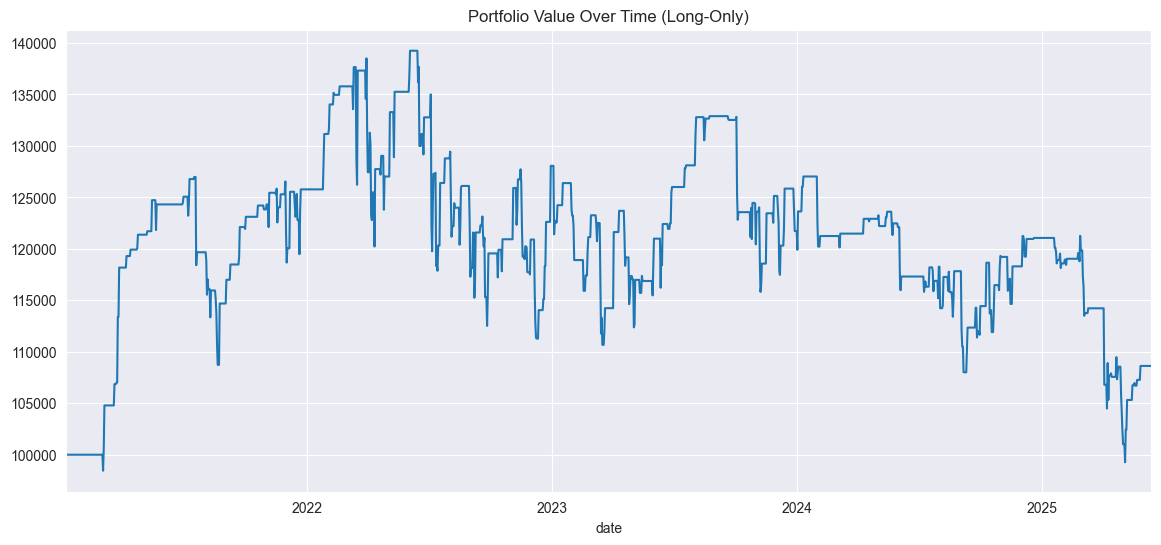


📈 Portfolio Values:
date
2021-01-06    100000.0
2021-01-07    100000.0
2021-01-08    100000.0
2021-01-09    100000.0
2021-01-10    100000.0
2021-01-11    100000.0
2021-01-12    100000.0
2021-01-13    100000.0
2021-01-14    100000.0
2021-01-15    100000.0
2021-01-16    100000.0
2021-01-17    100000.0
2021-01-18    100000.0
2021-01-19    100000.0
2021-01-20    100000.0
2021-01-21    100000.0
2021-01-22    100000.0
2021-01-23    100000.0
2021-01-24    100000.0
2021-01-25    100000.0
Name: group, dtype: float64

📉 Daily Returns:
date
2021-01-06    0.0
2021-01-07    0.0
2021-01-08    0.0
2021-01-09    0.0
2021-01-10    0.0
2021-01-11    0.0
2021-01-12    0.0
2021-01-13    0.0
2021-01-14    0.0
2021-01-15    0.0
2021-01-16    0.0
2021-01-17    0.0
2021-01-18    0.0
2021-01-19    0.0
2021-01-20    0.0
2021-01-21    0.0
2021-01-22    0.0
2021-01-23    0.0
2021-01-24    0.0
2021-01-25    0.0
Name: group, dtype: float64


In [86]:
# Portfolio.from_orders ile Long-Only Backtest
pf = vbt.Portfolio.from_orders(
    close=price_df,
    size=weights,
    size_type='targetpercent',
    init_cash=100000,
    freq="D",
    cash_sharing=True,
    call_seq='auto'
)

print("="*70)
print("📊 Portfolio Stats (from_orders - Long Only)")
print("="*70)

full_stats = pf.stats()
ret_stats = pf.returns_stats()
ann_factor = pf.returns().vbt.returns().ann_factor

print(f"\nAnn Factor:                         {ann_factor}")
print(f"Total Return [%]:                   {full_stats['Total Return [%]']:.3f}%")
print(f"Annualized Expected Return [%]:     {(pf.returns().mean() * ann_factor * 100):.3f}%")
print(f"Annualized Expected Volatility [%]: {(pf.returns().std() * (ann_factor ** 0.5) * 100):.3f}%")
print(f"Sharpe Ratio:                       {full_stats['Sharpe Ratio']:.3f}")
print(f"Sharpe Ratio (Manuel):              {((pf.returns().mean() * ann_factor)/(pf.returns().std() * (ann_factor ** 0.5))):.3f}")
print(f"Max Drawdown [%]:                   {full_stats['Max Drawdown [%]']:.3f}%")

# Portföy değeri grafiği
pf.value().plot(figsize=(14, 6), title='Portfolio Value Over Time (Long-Only)')
plt.show()

print("\n📈 Portfolio Values:")
print(pf.value().head(20))
print("\n📉 Daily Returns:")
print(pf.returns().head(20))

### Buy & Hold Stratejisi ile Karşılaştırma

In [82]:
# Buy & Hold stratejisi (aynı dönem için)
pf_buyhold = vbt.Portfolio.from_holding(
    close=test_prices,
    init_cash=100000
)

print("📊 Buy & Hold Strategy:")
print("="*70)
print(pf_buyhold.stats())

# Karşılaştırma
print("\n" + "="*70)
print("📈 PERFORMANS KARŞILAŞTIRMASI (CO1 Comdty)")
print("="*70)

timegpt_return = pf_timegpt.total_return() * 100
buyhold_return = pf_buyhold.total_return() * 100

# Ortalama günlük getiri ve standart sapma
timegpt_avg_return = pf_timegpt.returns().mean() * 100
buyhold_avg_return = pf_buyhold.returns().mean() * 100
timegpt_avg_std = pf_timegpt.returns().std() * 100
buyhold_avg_std = pf_buyhold.returns().std() * 100

timegpt_sharpe = pf_timegpt.sharpe_ratio()
buyhold_sharpe = pf_buyhold.sharpe_ratio()

timegpt_maxdd = pf_timegpt.max_drawdown() * 100
buyhold_maxdd = pf_buyhold.max_drawdown() * 100

print(f"\n{'Metrik':<25} | {'TimeGPT':>15} | {'Buy & Hold':>15}")
print("-"*60)
print(f"{'Toplam Getiri (%)':<25} | {timegpt_return:>14.2f}% | {buyhold_return:>14.2f}%")
print(f"{'Ortalama Günlük Getiri (%)':<25} | {timegpt_avg_return:>14.4f}% | {buyhold_avg_return:>14.4f}%")
print(f"{'Ortalama Günlük Std (%)':<25} | {timegpt_avg_std:>14.4f}% | {buyhold_avg_std:>14.4f}%")
print(f"{'Sharpe Ratio':<25} | {timegpt_sharpe:>15.2f} | {buyhold_sharpe:>15.2f}")
print(f"{'Max Drawdown (%)':<25} | {timegpt_maxdd:>14.2f}% | {buyhold_maxdd:>14.2f}%")

alpha = timegpt_return - buyhold_return
print(f"\n{'Alpha (Fazla Getiri):':<25} {alpha:+.2f}%")

📊 Buy & Hold Strategy:
Start                         2021-01-06 00:00:00
End                           2025-06-13 00:00:00
Period                         1620 days 00:00:00
Start Value                              100000.0
End Value                           137311.233886
Total Return [%]                        37.311234
Benchmark Return [%]                    37.311234
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        52.937959
Max Drawdown Duration          1193 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                       37311.233886
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]       

### Görselleştirme: TimeGPT vs Buy&Hold

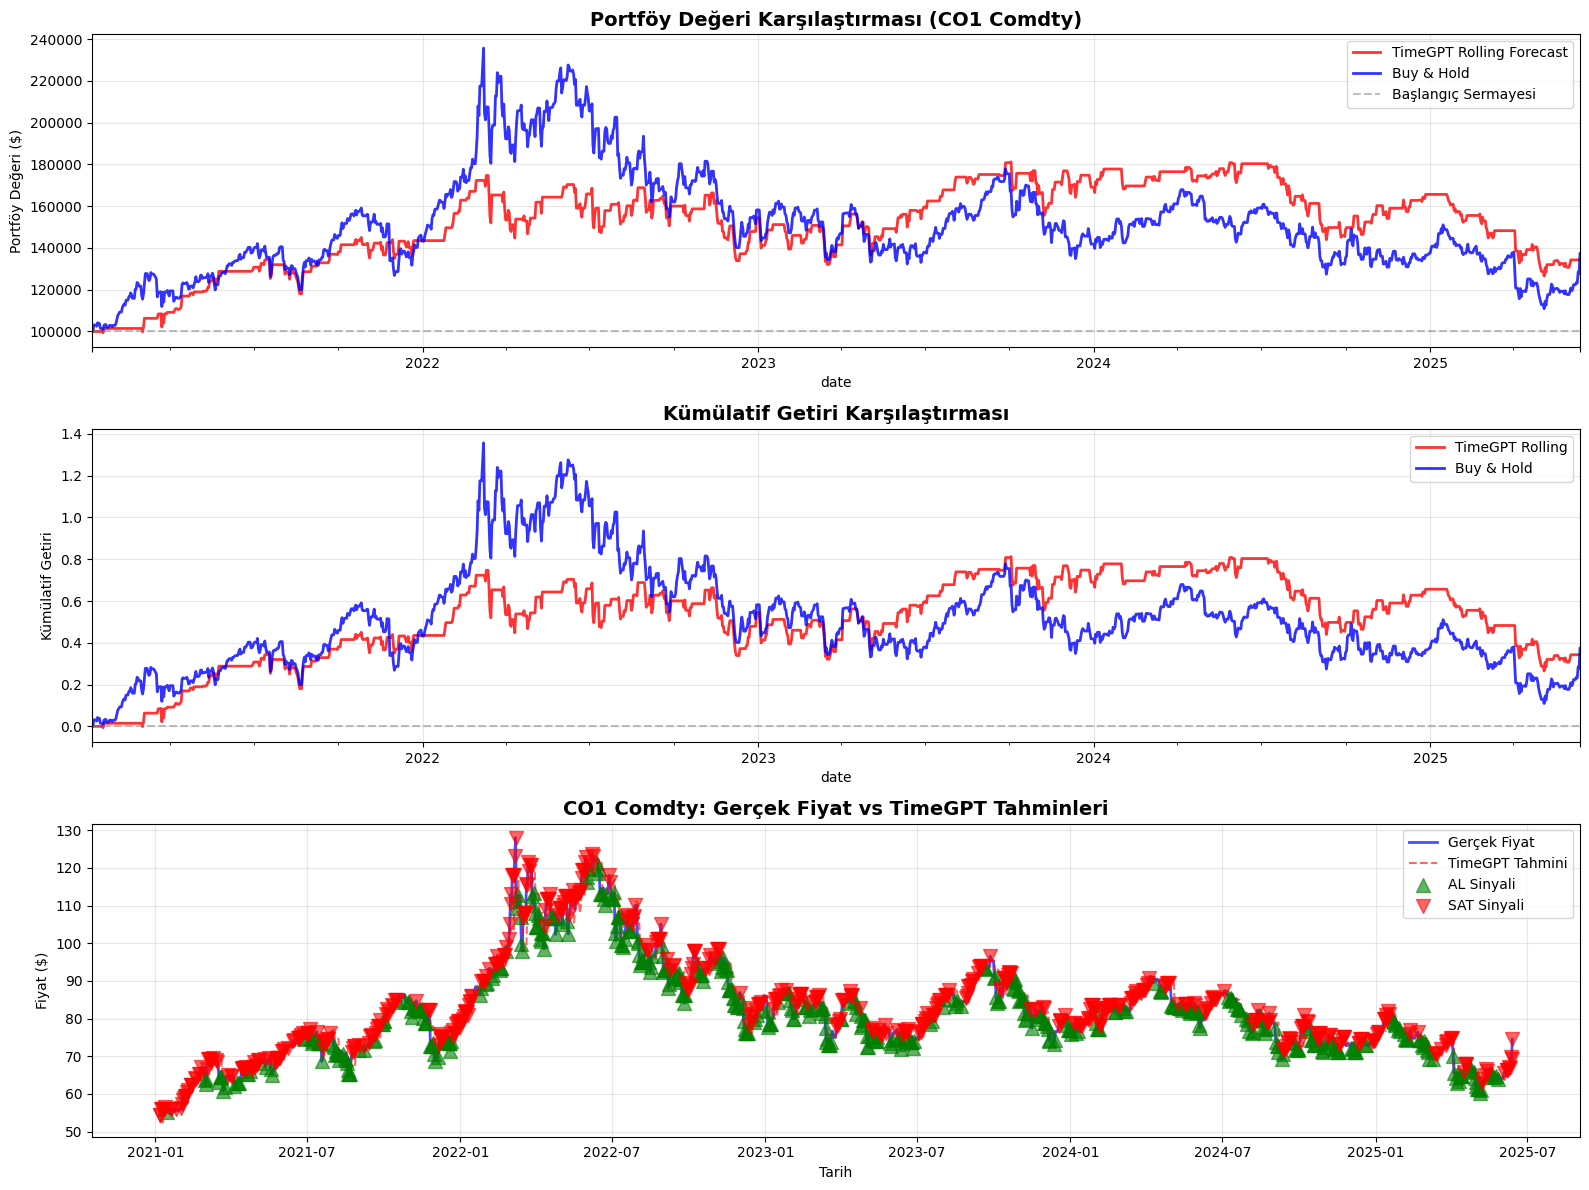

In [83]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Portföy Değeri Karşılaştırması
ax1 = axes[0]
pf_timegpt.value().plot(ax=ax1, label='TimeGPT Rolling Forecast', 
                         color='red', linewidth=2, alpha=0.8)
pf_buyhold.value().plot(ax=ax1, label='Buy & Hold', 
                        color='blue', linewidth=2, alpha=0.8)
ax1.axhline(y=100000, color='gray', linestyle='--', alpha=0.5, label='Başlangıç Sermayesi')
ax1.set_title('Portföy Değeri Karşılaştırması (CO1 Comdty)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Portföy Değeri ($)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Kümülatif Getiri
ax2 = axes[1]
pf_timegpt.cumulative_returns().plot(ax=ax2, label='TimeGPT Rolling', 
                                      color='red', linewidth=2, alpha=0.8)
pf_buyhold.cumulative_returns().plot(ax=ax2, label='Buy & Hold', 
                                      color='blue', linewidth=2, alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Kümülatif Getiri Karşılaştırması', 
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Kümülatif Getiri')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Tahmin vs Gerçek Fiyatlar
ax3 = axes[2]
ax3.plot(rolling_results.index, rolling_results['actual_price'], 
         label='Gerçek Fiyat', color='blue', linewidth=2, alpha=0.7)
ax3.plot(rolling_results.index, rolling_results['predicted_price'], 
         label='TimeGPT Tahmini', color='red', linewidth=1.5, 
         alpha=0.6, linestyle='--')

# Sinyalleri işaretle
buy_signals = rolling_results[rolling_results['signal'] == 1]
sell_signals = rolling_results[rolling_results['signal'] == -1]

ax3.scatter(buy_signals.index, buy_signals['actual_price'], 
           color='green', marker='^', s=100, alpha=0.6, label='AL Sinyali', zorder=5)
ax3.scatter(sell_signals.index, sell_signals['actual_price'], 
           color='red', marker='v', s=100, alpha=0.6, label='SAT Sinyali', zorder=5)

ax3.set_title('CO1 Comdty: Gerçek Fiyat vs TimeGPT Tahminleri', 
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Tarih')
ax3.set_ylabel('Fiyat ($)')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tahmin Doğruluğu Analizi

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Tahmin doğruluğu metrikleri
mae = mean_absolute_error(rolling_results['future_actual_price'], 
                          rolling_results['predicted_price'])
mse = mean_squared_error(rolling_results['future_actual_price'], 
                         rolling_results['predicted_price'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(rolling_results['future_actual_price'], 
                                      rolling_results['predicted_price']) * 100

# Yön doğruluğu (direction accuracy)
actual_direction = np.sign(rolling_results['actual_return'])
predicted_direction = np.sign(rolling_results['expected_return'])
direction_accuracy = (actual_direction == predicted_direction).mean() * 100

print("TAHMIN DOĞRULUĞU METRİKLERİ")
print(f"MAE (Mean Absolute Error):        ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error):   ${rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):     {mape:.2f}%")
print(f"\nYön Doğruluğu (Direction Accuracy): {direction_accuracy:.2f}%")

# Sinyal analizi
total_signals = len(rolling_results[rolling_results['signal'] != 0])
buy_signals_count = len(rolling_results[rolling_results['signal'] == 1])
sell_signals_count = len(rolling_results[rolling_results['signal'] == -1])

print(f"\n SİNYAL İSTATİSTİKLERİ")
print(f"Toplam Sinyal:     {total_signals}")
print(f"AL Sinyali:        {buy_signals_count} (%{buy_signals_count/len(rolling_results)*100:.1f})")
print(f"SAT Sinyali:       {sell_signals_count} (%{sell_signals_count/len(rolling_results)*100:.1f})")
print(f"TUT (Sinyal Yok):  {len(rolling_results) - total_signals} (%{(len(rolling_results)-total_signals)/len(rolling_results)*100:.1f})")

# Karlı işlem analizi
profitable_buys = rolling_results[(rolling_results['signal'] == 1) & 
                                  (rolling_results['actual_return'] > 0)]
profitable_sells = rolling_results[(rolling_results['signal'] == -1) & 
                                   (rolling_results['actual_return'] < 0)]

if buy_signals_count > 0:
    buy_success_rate = len(profitable_buys) / buy_signals_count * 100
    print(f"\nAL Sinyali Başarı Oranı:  {buy_success_rate:.2f}%")

if sell_signals_count > 0:
    sell_success_rate = len(profitable_sells) / sell_signals_count * 100
    print(f"SAT Sinyali Başarı Oranı: {sell_success_rate:.2f}%")

TAHMIN DOĞRULUĞU METRİKLERİ
MAE (Mean Absolute Error):        $2.29
RMSE (Root Mean Squared Error):   $3.27
MAPE (Mean Absolute % Error):     2.73%

Yön Doğruluğu (Direction Accuracy): 34.94%

 SİNYAL İSTATİSTİKLERİ
Toplam Sinyal:     1062
AL Sinyali:        524 (%32.3)
SAT Sinyali:       538 (%33.2)
TUT (Sinyal Yok):  558 (%34.4)

AL Sinyali Başarı Oranı:  39.12%
SAT Sinyali Başarı Oranı: 32.90%
